In [1]:
### plot arctic amp of warming vs arctic amp of cooling, across the GeoMIP G6 models, and ARISE. 

In [2]:
## NB - CEDA incident Nov 25 (deleted 1/3 of the CMIp6 archive) means this code doesn't run as of Nov 27th
## .. this should fix itself automatically in a month or two when data is restored. 

In [3]:
import os
import glob
import pandas as pd
import numpy as np
#import esmvalcore.preprocessor
import xarray as xr
from tqdm import tqdm
from xmip.preprocessing import rename_cmip6
import dask
from tqdm import tqdm
from nc_processing import calc_spatial_mean
import matplotlib.pyplot as plt

In [4]:
maxensmems = 5

In [5]:
def read_in(dir):
    files = []
    for x in os.listdir(dir):
        files.append(dir + x)
    # drop extraneous data from cesm G6sulfur runs:
    for file in excluded_files:
        files = [s for s in files if not file in s]
    #print(files)
    with dask.config.set(**{'array.slicing.split_large_chunks': True}):
        ds = rename_cmip6(xr.open_mfdataset(files, use_cftime=True, engine='netcdf4'))
    return ds

models = ['UKESM1-0-LL', 'IPSL-CM6A-LR', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'CESM2-WACCM', 'CNRM-ESM2-1']
cmip_scens = ['piControl', 'historical', 'ssp245', 'ssp585']

lat_bnds_global = [-91, 91]
lat_bnds_arctic = [66, 91]
lat_bnds_antarctic = [-91, -66]
lat_bnds_tropics = [-30, 30]

regions_dict = {'global':lat_bnds_global,
                'arctic':lat_bnds_arctic,
                'antarctic':lat_bnds_antarctic,
                'tropics':lat_bnds_tropics}

excluded_runs = ['/UKESM1-0-LL/historical/r10i1p1f2/',
                 '/MPI-ESM1-2-HR/historical/r8i1p1f1/']

excluded_files = ['tas_Amon_CESM2-WACCM_G6sulfur_r1i1p1f2_gn_202001-206912.nc',
                  'tas_Amon_CESM2-WACCM_G6sulfur_r2i1p1f2_gn_201501-206412.nc',
                  'tas_Amon_CESM2-WACCM_G6sulfur_r2i1p1f2_gn_206501-210012.nc',
                  'tas_Amon_CESM2-WACCM_G6sulfur_r1i1p1f2_gn_207001-210012.nc']

def get_temps_ds(dir):
    ds = read_in(dir)
    out_ds_list = []
    for region in regions_dict.keys():
        lat_bnds = regions_dict[region]
        da_r = ds.sel(y=slice(lat_bnds[0], lat_bnds[1])).tas
        da_r = calc_spatial_mean(da_r, lon_name="x", lat_name="y")
        da_r = da_r.to_dataset().rename({'tas':'tas_{}'.format(region)})
        out_ds_list.append(da_r)
    out_ds = xr.merge(out_ds_list)
    return out_ds

def get_temps_ds_file(file, var_rename=None):
    ds = rename_cmip6(xr.open_dataset(file, use_cftime=True, engine='netcdf4'))
    if var_rename:
        ds = ds.rename(var_rename)
    out_ds_list = []
    for region in regions_dict.keys():
        lat_bnds = regions_dict[region]
        da_r = ds.sel(y=slice(lat_bnds[0], lat_bnds[1])).tas
        da_r = calc_spatial_mean(da_r, lon_name="x", lat_name="y")
        da_r = da_r.to_dataset().rename({'tas':'tas_{}'.format(region)})
        out_ds_list.append(da_r)
    out_ds = xr.merge(out_ds_list)
    return out_ds


## for GeoMIP files, use a mix of my .synda archive, and the CEDA archive, to get the fullest list possible:
GeoMIP_dirs =  ['/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6solar/r1i1p1f2/Amon/tas/gr/latest/',
                '/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r1i1p1f2/Amon/tas/gr/latest/',
                '/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r2i1p1f2/Amon/tas/gr/latest/',
                '/badc/cmip6/data/CMIP6/GeoMIP/CNRM-CERFACS/CNRM-ESM2-1/G6sulfur/r3i1p1f2/Amon/tas/gr/latest/',
                '/badc/cmip6/data/CMIP6/GeoMIP/IPSL/IPSL-CM6A-LR/G6solar/r1i1p1f1/Amon/tas/gr/latest/',
                '/badc/cmip6/data/CMIP6/GeoMIP/IPSL/IPSL-CM6A-LR/G6sulfur/r1i1p1f1/Amon/tas/gr/latest/',
                '/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6solar/r1i1p1f2/Amon/tas/gn/latest/',
                '/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6solar/r4i1p1f2/Amon/tas/gn/latest/',
                '/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6solar/r8i1p1f2/Amon/tas/gn/latest/',
                '/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r1i1p1f2/Amon/tas/gn/latest/',
                '/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r4i1p1f2/Amon/tas/gn/latest/',
                '/badc/cmip6/data/CMIP6/GeoMIP/MOHC/UKESM1-0-LL/G6sulfur/r8i1p1f2/Amon/tas/gn/latest/',
                '/badc/cmip6/data/CMIP6/GeoMIP/MPI-M/MPI-ESM1-2-HR/G6solar/r1i1p1f1/Amon/tas/gn/latest/',
                '/gws/ssde/j25b/cpom/aduffey/.synda/data/CMIP6/GeoMIP/MPI-M/MPI-ESM1-2-HR/G6solar/r2i1p1f1/Amon/tas/gn/v20190710/',
                '/gws/ssde/j25b/cpom/aduffey/.synda/data/CMIP6/GeoMIP/MPI-M/MPI-ESM1-2-HR/G6solar/r3i1p1f1/Amon/tas/gn/v20190710/',
                '/badc/cmip6/data/CMIP6/GeoMIP/MPI-M/MPI-ESM1-2-HR/G6sulfur/r1i1p1f1/Amon/tas/gn/latest/',
                '/badc/cmip6/data/CMIP6/GeoMIP/MPI-M/MPI-ESM1-2-HR/G6sulfur/r2i1p1f1/Amon/tas/gn/latest/',
                '/badc/cmip6/data/CMIP6/GeoMIP/MPI-M/MPI-ESM1-2-HR/G6sulfur/r3i1p1f1/Amon/tas/gn/latest/',
                '/badc/cmip6/data/CMIP6/GeoMIP/MPI-M/MPI-ESM1-2-LR/G6solar/r1i1p1f1/Amon/tas/gn/latest/',
                '/badc/cmip6/data/CMIP6/GeoMIP/MPI-M/MPI-ESM1-2-LR/G6solar/r2i1p1f1/Amon/tas/gn/latest/',
                '/badc/cmip6/data/CMIP6/GeoMIP/MPI-M/MPI-ESM1-2-LR/G6solar/r3i1p1f1/Amon/tas/gn/latest/',
                '/badc/cmip6/data/CMIP6/GeoMIP/MPI-M/MPI-ESM1-2-LR/G6sulfur/r1i1p1f1/Amon/tas/gn/latest/',
                '/badc/cmip6/data/CMIP6/GeoMIP/MPI-M/MPI-ESM1-2-LR/G6sulfur/r2i1p1f1/Amon/tas/gn/latest/',
                '/badc/cmip6/data/CMIP6/GeoMIP/MPI-M/MPI-ESM1-2-LR/G6sulfur/r3i1p1f1/Amon/tas/gn/latest/',
                '/badc/cmip6/data/CMIP6/GeoMIP/NCAR/CESM2-WACCM/G6solar/r1i1p1f1/Amon/tas/gn/latest/',
                '/gws/ssde/j25b/cpom/aduffey/.synda/data/CMIP6/GeoMIP/NCAR/CESM2-WACCM/G6solar/r1i2p1f1/Amon/tas/gn/v20191120/',
                '/badc/cmip6/data/CMIP6/GeoMIP/NCAR/CESM2-WACCM/G6sulfur/r1i1p1f2/Amon/tas/gn/latest/',
                '/badc/cmip6/data/CMIP6/GeoMIP/NCAR/CESM2-WACCM/G6sulfur/r2i1p1f2/Amon/tas/gn/latest/']

## also save scenarioMIP dirs
cmip_dirs = []
for model in models:
    for scenario in cmip_scens:
        for x in glob.glob('/badc/cmip6/data/CMIP6/*/*/{m}/{s}/*/Amon/tas/*/latest/'.format(m=model, s=scenario)):
            cmip_dirs.append(x)
for path in excluded_runs:
    cmip_dirs = [s for s in cmip_dirs if not path in s]

In [6]:
os.listdir('/gws/ssde/j25b/cpom/aduffey/ARISE/CESM/arise/TREFHT/')

['b.e21.BW.f09_g17.SSP245-TSMLT-GAUSS-DEFAULT.003.cam.h0.TREFHT.203501-206912.nc',
 'b.e21.BW.f09_g17.SSP245-TSMLT-GAUSS-DEFAULT.010.cam.h0.TREFHT.203501-206912.nc',
 'b.e21.BW.f09_g17.SSP245-TSMLT-GAUSS-DEFAULT.006.cam.h0.TREFHT.203501-206912.nc',
 'b.e21.BW.f09_g17.SSP245-TSMLT-GAUSS-DEFAULT.005.cam.h0.TREFHT.203501-206912.nc',
 'b.e21.BW.f09_g17.SSP245-TSMLT-GAUSS-DEFAULT.009.cam.h0.TREFHT.203501-207012.nc',
 'b.e21.BW.f09_g17.SSP245-TSMLT-GAUSS-DEFAULT.007.cam.h0.TREFHT.203501-206912.nc',
 'b.e21.BW.f09_g17.SSP245-TSMLT-GAUSS-DEFAULT.002.cam.h0.TREFHT.203501-206912.nc',
 '.md5_results',
 'b.e21.BW.f09_g17.SSP245-TSMLT-GAUSS-DEFAULT.001.cam.h0.TREFHT.203501-206912.nc',
 'b.e21.BW.f09_g17.SSP245-TSMLT-GAUSS-DEFAULT.008.cam.h0.TREFHT.203501-207012.nc',
 'b.e21.BW.f09_g17.SSP245-TSMLT-GAUSS-DEFAULT.004.cam.h0.TREFHT.203501-206912.nc']

In [7]:

UKESM_arise_dirs = glob.glob('/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/*/Amon/tas/*/*/')
CESM_arise_dir = '/gws/ssde/j25b/cpom/aduffey/ARISE/CESM/arise/TREFHT/'

CESM_ARISE_files = [s for s in os.listdir(CESM_arise_dir) if ".nc" in s] # filter out any junk in the dir
CESM_ARISE_files = [CESM_arise_dir+x for x in CESM_ARISE_files][0:maxensmems]



In [8]:
t_bnds = {'G6sulfur':{'start':'2080', 'end':'2100'},
          'G6solar':{'start':'2080', 'end':'2100'},
          #'historical':{'start':'1980', 'end':'2000'},
          'ssp245_baseline':{'start':'2015', 'end':'2035'},
          'ssp245':{'start':'2080', 'end':'2100'},
          'ssp585':{'start':'2080', 'end':'2100'}, 
          'ssp245_arise_ref':{'start':'2050', 'end':'2070'},
          'ARISE':{'start':'2050', 'end':'2070'}, 
          'G4':{'start':'2050', 'end':'2069'},
          'G3':{'start':'2050', 'end':'2069'},
          'rcp45_G3G4':{'start':'2050', 'end':'2069'},
          'rcp45_baseline':{'start':'2015', 'end':'2035'}}



In [9]:
arise_mods = ['UKESM1-0-LL', 'CESM2-WACCM']

In [10]:
ds_dict_mod_list = []
for model in models:
    print(model)
    G6sulfur_dirs = [x for x in GeoMIP_dirs if model in x and 'G6sulfur' in x]
    G6solar_dirs = [x for x in GeoMIP_dirs if model in x and 'G6solar' in x]
    hist_dirs = [x for x in cmip_dirs if model in x and 'historical' in x]
    ssp245_dirs = [x for x in cmip_dirs if model in x and 'ssp245' in x]
    ssp585_dirs = [x for x in cmip_dirs if model in x and 'ssp585' in x]
    #arise_dirs = [x for x in arise_dirs if model in x]

    ## read in data:
    ds_G6sulfur = xr.concat([get_temps_ds(x) for x in G6sulfur_dirs], dim='Ensemble_member').sel(time=slice(t_bnds['G6sulfur']['start'], t_bnds['G6sulfur']['end'])).mean('time')
    ds_G6solar = xr.concat([get_temps_ds(x) for x in G6solar_dirs], dim='Ensemble_member').sel(time=slice(t_bnds['G6solar']['start'], t_bnds['G6solar']['end'])).mean('time')

    ds_ssp245_baseline = xr.concat([get_temps_ds(x) for x in ssp245_dirs[0:maxensmems]], dim='Ensemble_member').sel(time=slice(t_bnds['ssp245_baseline']['start'], t_bnds['ssp245_baseline']['end'])).mean('time')
    ds_ssp245 = xr.concat([get_temps_ds(x) for x in ssp245_dirs[0:maxensmems]], dim='Ensemble_member').sel(time=slice(t_bnds['ssp245']['start'], t_bnds['ssp245']['end'])).mean('time')
    ds_ssp585 = xr.concat([get_temps_ds(x) for x in ssp585_dirs[0:maxensmems]], dim='Ensemble_member').sel(time=slice(t_bnds['ssp585']['start'], t_bnds['ssp585']['end'])).mean('time')

    if model == 'UKESM1-0-LL':
        ds_ssp245_arise_ref = xr.concat([get_temps_ds(x) for x in ssp245_dirs[0:maxensmems]], dim='Ensemble_member').sel(time=slice(t_bnds['ssp245_arise_ref']['start'], t_bnds['ssp245_arise_ref']['end'])).mean('time')
        ds_arise = xr.concat([get_temps_ds(x) for x in UKESM_arise_dirs[0:maxensmems]], dim='Ensemble_member').sel(time=slice(t_bnds['ARISE']['start'], t_bnds['ARISE']['end'])).mean('time')
        ds_ssp245_arise_ref['Experiment'] = 'ssp245_arise_ref'
        ds_arise['Experiment'] = 'ARISE'

    if model == 'CESM2-WACCM':
        ds_ssp245_arise_ref = xr.concat([get_temps_ds(x) for x in ssp245_dirs[0:maxensmems]], dim='Ensemble_member').sel(time=slice(t_bnds['ssp245_arise_ref']['start'], t_bnds['ssp245_arise_ref']['end'])).mean('time')
        ds_arise = xr.concat([get_temps_ds_file(x, var_rename={'TREFHT':'tas'}) for x in CESM_ARISE_files], dim='Ensemble_member').sel(time=slice(t_bnds['ARISE']['start'], t_bnds['ARISE']['end'])).mean('time')
        ds_ssp245_arise_ref['Experiment'] = 'ssp245_arise_ref'
        ds_arise['Experiment'] = 'ARISE'

    ds_G6sulfur['Experiment'] = 'G6sulfur'
    ds_G6solar['Experiment'] = 'G6solar'

    ds_ssp245_baseline['Experiment'] = 'ssp245_baseline'
    
    ds_ssp245['Experiment'] = 'ssp245'
    ds_ssp585['Experiment'] = 'ssp585'

    if model in arise_mods:
        ds_dict_mod = dict(zip(['G6sulfur', 'G6solar', 'ssp245_baseline', 'ARISE', 'ssp245_arise_ref', 'ssp245', 'ssp585'], [ds_G6sulfur, ds_G6solar, ds_ssp245_baseline, ds_arise, ds_ssp245_arise_ref, ds_ssp245, ds_ssp585]))
    else:
        ds_dict_mod = dict(zip(['G6sulfur', 'G6solar', 'ssp245_baseline', 'ssp245', 'ssp585'], [ds_G6sulfur, ds_G6solar, ds_ssp245_baseline, ds_ssp245, ds_ssp585]))
    ds_dict_mod_list.append(ds_dict_mod)

ds_dict = dict(zip(models, ds_dict_mod_list))


UKESM1-0-LL
IPSL-CM6A-LR
MPI-ESM1-2-HR
MPI-ESM1-2-LR
CESM2-WACCM


/home/users/a_duffey/.conda/envs/main2/lib/python3.12/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'tas' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/users/a_duffey/.conda/envs/main2/lib/python3.12/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'tas' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/users/a_duffey/.conda/envs/main2/lib/python3.12/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'tas' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/users/a_duffey/.conda/envs/main2/lib/python3.12/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'tas' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/users/a_du

CNRM-ESM2-1


In [11]:
## now get temp anoms, and plot: 

## NB - important to use [ssp585 - ssp245] not [spp245 - ssp245_baseline] for warming for the G6 case, since there is less AA for the former (already loast more sea ice), but that is the fair comparison for G6 runs. 

out_dicts = []
for model in models:

    arctic_warming = ds_dict[model]['ssp585'].tas_arctic - ds_dict[model]['ssp245'].tas_arctic.mean('Ensemble_member')
    arctic_cooling_G6sulfur = ds_dict[model]['G6sulfur'].tas_arctic - ds_dict[model]['ssp585'].tas_arctic.mean('Ensemble_member')
    arctic_cooling_G6solar = ds_dict[model]['G6solar'].tas_arctic - ds_dict[model]['ssp585'].tas_arctic.mean('Ensemble_member')
    
    global_warming = ds_dict[model]['ssp585'].tas_global - ds_dict[model]['ssp245'].tas_global.mean('Ensemble_member')
    global_cooling_G6sulfur = ds_dict[model]['G6sulfur'].tas_global - ds_dict[model]['ssp585'].tas_global.mean('Ensemble_member')
    global_cooling_G6solar = ds_dict[model]['G6solar'].tas_global - ds_dict[model]['ssp585'].tas_global.mean('Ensemble_member')
    
    
    arctic_amp_warming = (arctic_warming / global_warming).values
    arctic_amp_cooling_G6sulfur = (arctic_cooling_G6sulfur / global_cooling_G6sulfur).values
    arctic_amp_cooling_G6solar = (arctic_cooling_G6solar / global_cooling_G6solar).values

    if model in arise_mods:
        arctic_warming_arise_ref = ds_dict[model]['ssp245_arise_ref'].tas_arctic - ds_dict[model]['ssp245_baseline'].tas_arctic.mean('Ensemble_member')
        global_warming_arise_ref = ds_dict[model]['ssp245_arise_ref'].tas_global - ds_dict[model]['ssp245_baseline'].tas_global.mean('Ensemble_member')
        arctic_cooling_arise = ds_dict[model]['ARISE'].tas_arctic - ds_dict[model]['ssp245_arise_ref'].tas_arctic.mean('Ensemble_member')
        global_cooling_arise = ds_dict[model]['ARISE'].tas_global - ds_dict[model]['ssp245_arise_ref'].tas_global.mean('Ensemble_member')
        arctic_amp_warming_arise = (arctic_warming_arise_ref / global_warming_arise_ref).values
        arctic_amp_cooling_arise = (arctic_cooling_arise / global_cooling_arise).values
    else:
        arctic_cooling_arise, global_cooling_arise = np.nan, np.nan
        arctic_amp_cooling_arise = np.nan
        arctic_amp_warming_arise = np.nan
    
    out_dicts.append({'warming_amp':arctic_amp_warming, 'cooling_amp_G6sulfur':arctic_amp_cooling_G6sulfur, 'cooling_amp_G6solar':arctic_amp_cooling_G6solar, 
                      'warming_amp_arise':arctic_amp_warming_arise, 'cooling_amp_ARISE':arctic_amp_cooling_arise})
    print(model, arctic_amp_warming, arctic_amp_cooling_G6sulfur, arctic_amp_cooling_G6solar, arctic_amp_cooling_arise)

out_df = pd.DataFrame(out_dicts, index=models)

UKESM1-0-LL [2.19411014 2.06400753 2.15177986 2.18988384 2.14596941] [1.75417432 1.76243452 1.63208316] [1.9773292  1.89791267 2.0308322 ] [2.3032454  2.52482488 2.3289197  2.2131901  2.20071647]
IPSL-CM6A-LR [2.37655338 2.31218771 2.28339895 2.22380553 2.30283593] [2.17577233] [2.25338074] nan
MPI-ESM1-2-HR [1.98753106 2.08547491] [1.31887777 1.21907525 1.34054573] [1.92065353 2.08898875 1.82080097] nan
MPI-ESM1-2-LR [2.25694755 2.13869449 2.19670854 2.40938671 2.11487123] [0.66855405 1.2772122  1.34845412] [1.12057323 1.78789435 1.85714789] nan
CESM2-WACCM [2.16626698 2.05955468 2.27766455 2.1559698  2.19079308] [2.42984427 2.27535408] [2.27809024 2.16674198] [2.31756628 2.43435891 1.90493872 2.20304415 2.31785153]
CNRM-ESM2-1 [2.48192208 2.31215905 2.22200467 1.96834479 2.21749216] [2.0903625  2.02762072 1.71227665] [2.41645994] nan


In [12]:
out_df

,warming_amp,cooling_amp_G6sulfur,cooling_amp_G6solar,warming_amp_arise,cooling_amp_ARISE
UKESM1-0-LL,"[2.1941101360800306, 2.0640075302168253, 2.151...","[1.7541743199611983, 1.7624345232982022, 1.632...","[1.9773292040899744, 1.8979126686221692, 2.030...","[3.029351993179802, 3.1165783782169365, 3.1142...","[2.303245403129382, 2.524824884332809, 2.32891..."
IPSL-CM6A-LR,"[2.3765533822588654, 2.3121877139949794, 2.283...",[2.1757723327247978],[2.2533807432907302],NaN,NaN
MPI-ESM1-2-HR,"[1.9875310645519204, 2.085474906227596]","[1.3188777706464243, 1.2190752504400866, 1.340...","[1.920653526315859, 2.0889887503094724, 1.8208...",NaN,NaN
MPI-ESM1-2-LR,"[2.256947550863658, 2.1386944872548503, 2.1967...","[0.6685540536876791, 1.2772121980023021, 1.348...","[1.1205732283312104, 1.7878943518463797, 1.857...",NaN,NaN
CESM2-WACCM,"[2.1662669787845843, 2.0595546813266354, 2.277...","[2.4298442714075303, 2.2753540812942417]","[2.2780902431575085, 2.1667419824045693]","[1.6921327939756616, 1.8378853484397002, 2.053...","[2.317566281394522, 2.4343589134046373, 1.9049..."
CNRM-ESM2-1,"[2.4819220760955383, 2.3121590521175572, 2.222...","[2.0903625005398516, 2.0276207179065997, 1.712...",[2.4164599412152943],NaN,NaN


In [13]:
# define a dict with colors for each model:
# use a nice color palette with some pzazz:
color_dict = {'UKESM1-0-LL':'#1f77b4',
                'IPSL-CM6A-LR':'#ff7f0e',
                'MPI-ESM1-2-HR':'#2ca02c',
                'MPI-ESM1-2-LR':'#d62728',
                'CESM2-WACCM':'#9467bd',
                'CNRM-ESM2-1':'#8c564b'}

In [14]:
# set default motplotlib fontsize to 16
plt.rcParams.update({'font.size': 16})

UKESM1-0-LL
IPSL-CM6A-LR
MPI-ESM1-2-HR
MPI-ESM1-2-LR
CESM2-WACCM
CNRM-ESM2-1


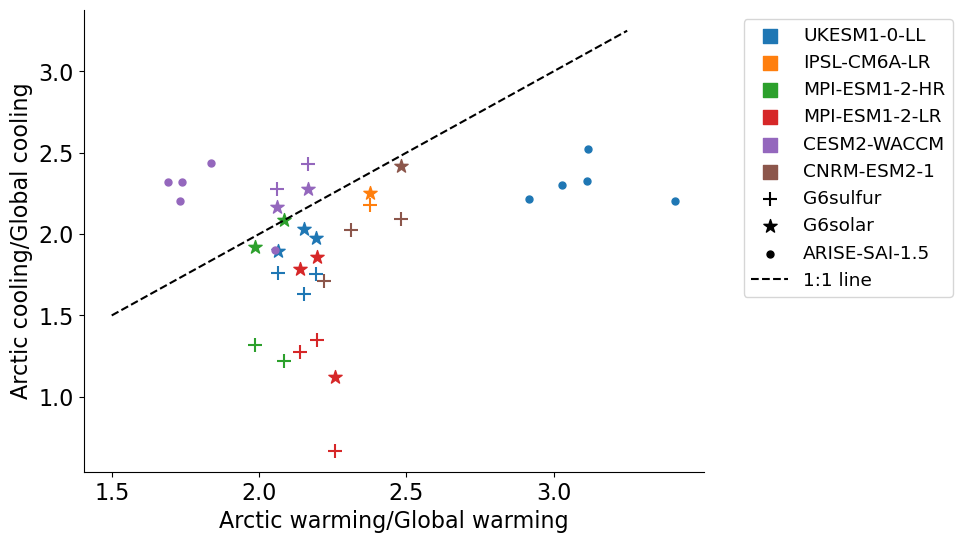

In [15]:
# scatter plot of out_df contents:

fig, ax = plt.subplots(figsize=(8,6))

for model in models:
    print(model)
    ax.scatter(out_df.loc[model, 'warming_amp'][0:len(out_df.loc[model, 'cooling_amp_G6sulfur'])], out_df.loc[model, 'cooling_amp_G6sulfur'][0:len(out_df.loc[model, 'warming_amp'])], color=color_dict[model], marker='+', s=100)
    ax.scatter(out_df.loc[model, 'warming_amp'][0:len(out_df.loc[model, 'cooling_amp_G6solar'])], out_df.loc[model, 'cooling_amp_G6solar'][0:len(out_df.loc[model, 'warming_amp'])], color=color_dict[model], marker='*', s=100)
    if model in arise_mods:
        ax.scatter(out_df.loc[model, 'warming_amp_arise'][0:len(out_df.loc[model, 'cooling_amp_ARISE'])], out_df.loc[model, 'cooling_amp_ARISE'], color=color_dict[model], marker='.', s=100)

    # dummy scatters for the legend:
    ax.scatter([], [], label=model, color=color_dict[model], marker='s', s=100)

# add legend for marker types:
ax.scatter([], [], label='G6sulfur', color='k', marker='+', s=100)
ax.scatter([], [], label='G6solar', color='k', marker='*', s=100)
ax.scatter([], [], label='ARISE-SAI-1.5', color='k', marker='.', s=100)

# one-to-one line
x = np.linspace(1.5, 3.25, 100)
ax.plot(x, x, color='k', linestyle='--', label='1:1 line')

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
ax.set_xlabel('Arctic warming/Global warming', fontsize='medium')
ax.set_ylabel('Arctic cooling/Global cooling', fontsize='medium')

ax.set_xticks(np.arange(1.5, 3.5, 0.5))
# remove right and top axes
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.savefig('arctic_amp_warming_vs_cooling_GeoMIP_G6_ARISE.png', bbox_inches='tight', dpi=300)

In [16]:
### now add G3/G4 data

## just read in the csv from last time i did this for now: 

dir_CMIP5_tas = '../../../Arctic_in_GeoMIP_and_Arise/processed_tas/'

g4_df = pd.read_csv(dir_CMIP5_tas+'GeoMIP_G4_tas_by_region.csv').groupby(['Model', 'Experiment', 'Ensemble_member', 'Year']).mean().reset_index()
g3_df = pd.read_csv(dir_CMIP5_tas+'GeoMIP_G3_tas_by_region.csv').groupby(['Model', 'Experiment', 'Ensemble_member', 'Year']).mean().reset_index()
CMIP5_df = pd.read_csv(dir_CMIP5_tas+'CMIP5_scens_tas_by_region.csv').groupby(['Model', 'Experiment', 'Ensemble_member', 'Year']).mean().reset_index()

G4_models = ['BNU-ESM', 'CSIRO-Mk3L-1-2', 'CanESM2', 'GISS-E2-R', 'HadGEM2-ES', 'MIROC-ESM', 'MIROC-ESM-CHEM', 'NorESM1-M']
# extra G3 model is just MPI - i add this by hand below


In [30]:
out_dicts_G4 = []
for model in G4_models:
    mod_df_g4 = g4_df[g4_df['Model'] == model]
    mod_df_rcp45 = CMIP5_df[(CMIP5_df['Model'] == model) & (CMIP5_df['Experiment'] == 'rcp45')]
    
    arctic_warming = mod_df_rcp45[mod_df_rcp45['Year'].between(int(t_bnds['rcp45_G3G4']['start']), int(t_bnds['rcp45_G3G4']['end']))].groupby('Ensemble_member').mean(['tas_arctic'])['tas_arctic'].values - np.mean(mod_df_rcp45[mod_df_rcp45['Year'].between(int(t_bnds['rcp45_baseline']['start']), int(t_bnds['rcp45_baseline']['end']))].groupby('Ensemble_member').mean(['tas_arctic'])['tas_arctic'].values)
    arctic_cooling_G4 = mod_df_g4[mod_df_g4['Year'].between(int(t_bnds['rcp45_G3G4']['start']), int(t_bnds['rcp45_G3G4']['end']))].groupby('Ensemble_member').mean(['tas_arctic'])['tas_arctic'].values - np.mean(mod_df_rcp45[mod_df_rcp45['Year'].between(int(t_bnds['rcp45_G3G4']['start']), int(t_bnds['rcp45_G3G4']['end']))].groupby('Ensemble_member').mean(['tas_arctic'])['tas_arctic'].values)
    
    global_warming = mod_df_rcp45[mod_df_rcp45['Year'].between(int(t_bnds['rcp45_G3G4']['start']), int(t_bnds['rcp45_G3G4']['end']))].groupby('Ensemble_member').mean(['tas_global'])['tas_global'].values - np.mean(mod_df_rcp45[mod_df_rcp45['Year'].between(int(t_bnds['rcp45_baseline']['start']), int(t_bnds['rcp45_baseline']['end']))].groupby('Ensemble_member').mean(['tas_global'])['tas_global'].values)
    global_cooling_G4 = mod_df_g4[mod_df_g4['Year'].between(int(t_bnds['rcp45_G3G4']['start']), int(t_bnds['rcp45_G3G4']['end']))].groupby('Ensemble_member').mean(['tas_global'])['tas_global'].values - np.mean(mod_df_rcp45[mod_df_rcp45['Year'].between(int(t_bnds['rcp45_G3G4']['start']), int(t_bnds['rcp45_G3G4']['end']))].groupby('Ensemble_member').mean(['tas_global'])['tas_global'].values)

    arctic_amp_warming = (arctic_warming / global_warming)
    arctic_amp_cooling_G4 = (arctic_cooling_G4 / global_cooling_G4)

    out_dicts_G4.append({'warming_amp':arctic_amp_warming, 'cooling_amp_G3G4':arctic_amp_cooling_G4})
    print(model, arctic_amp_warming, arctic_amp_cooling_G4)

out_df_G4 = pd.DataFrame(out_dicts_G4, index=G4_models).drop('CanESM2')  # drop CanESM2 as it had no ensemble members

# now also get G3 for 'MPI-ESM-LR'
model = 'MPI-ESM-LR'
mod_df_g3 = g3_df[g3_df['Model'] == model]
mod_df_rcp45 = CMIP5_df[(CMIP5_df['Model'] == model) & (CMIP5_df['Experiment'] == 'rcp45')]
arctic_warming = mod_df_rcp45[mod_df_rcp45['Year'].between(int(t_bnds['rcp45_G3G4']['start']), int(t_bnds['rcp45_G3G4']['end']))].groupby('Ensemble_member').mean(['tas_arctic'])['tas_arctic'].values - np.mean(mod_df_rcp45[mod_df_rcp45['Year'].between(int(t_bnds['rcp45_baseline']['start']), int(t_bnds['rcp45_baseline']['end']))].groupby('Ensemble_member').mean(['tas_arctic'])['tas_arctic'].values)
arctic_cooling_G3 = mod_df_g3[mod_df_g3['Year'].between(int(t_bnds['rcp45_G3G4']['start']), int(t_bnds['rcp45_G3G4']['end']))].groupby('Ensemble_member').mean(['tas_arctic'])['tas_arctic'].values - np.mean(mod_df_rcp45[mod_df_rcp45['Year'].between(int(t_bnds['rcp45_G3G4']['start']), int(t_bnds['rcp45_G3G4']['end']))].groupby('Ensemble_member').mean(['tas_arctic'])['tas_arctic'].values)
global_warming = mod_df_rcp45[mod_df_rcp45['Year'].between(int(t_bnds['rcp45_G3G4']['start']), int(t_bnds['rcp45_G3G4']['end']))].groupby('Ensemble_member').mean(['tas_global'])['tas_global'].values - np.mean(mod_df_rcp45[mod_df_rcp45['Year'].between(int(t_bnds['rcp45_baseline']['start']), int(t_bnds['rcp45_baseline']['end']))].groupby('Ensemble_member').mean(['tas_global'])['tas_global'].values)
global_cooling_G3 = mod_df_g3[mod_df_g3['Year'].between(int(t_bnds['rcp45_G3G4']['start']), int(t_bnds['rcp45_G3G4']['end']))].groupby('Ensemble_member').mean(['tas_global'])['tas_global'].values - np.mean(mod_df_rcp45[mod_df_rcp45['Year'].between(int(t_bnds['rcp45_G3G4']['start']), int(t_bnds['rcp45_G3G4']['end']))].groupby('Ensemble_member').mean(['tas_global'])['tas_global'].values)
arctic_amp_warming = (arctic_warming / global_warming)
arctic_amp_cooling_G3 = (arctic_cooling_G3 / global_cooling_G3)
out_df_G4.loc['MPI-ESM-LR'] = {'warming_amp':arctic_amp_warming, 'cooling_amp_G3G4':arctic_amp_cooling_G3}


# could drop ensemble member 1 MPI-ESM-LR as there is an issue with the data (see plots in following cell)
# We keep it in by commenting line below
#out_df_G4.loc['MPI-ESM-LR'] = {'warming_amp':out_df_G4.loc['MPI-ESM-LR']['warming_amp'][1:], 'cooling_amp_G3G4':out_df_G4.loc['MPI-ESM-LR']['cooling_amp_G3G4'][1:]}

BNU-ESM [2.46854459] [2.83335208]
CSIRO-Mk3L-1-2 [1.47083194 1.18457658 2.02523367] [1.20795011 1.47442829 0.11804911]
CanESM2 [] [nan nan nan]
GISS-E2-R [1.88598876 1.99101222 2.23593047 2.27236095 1.75955836 1.447916  ] [4.16002948 3.6537536  3.77390737]
HadGEM2-ES [3.30737058 2.54957332 3.03843301 2.77095317] [2.25492803 2.33239201 2.78005428]
MIROC-ESM [2.47891602] [2.38079365]
MIROC-ESM-CHEM [2.57693067] [1.55734837]
NorESM1-M [2.51063031] [2.40230773]


/home/users/a_duffey/.conda/envs/main2/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/users/a_duffey/.conda/envs/main2/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/users/a_duffey/.conda/envs/main2/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/users/a_duffey/.conda/envs/main2/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/users/a_duffey/.conda/envs/main2/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/users/a_duffey/.conda/envs/main2/lib/python3.1

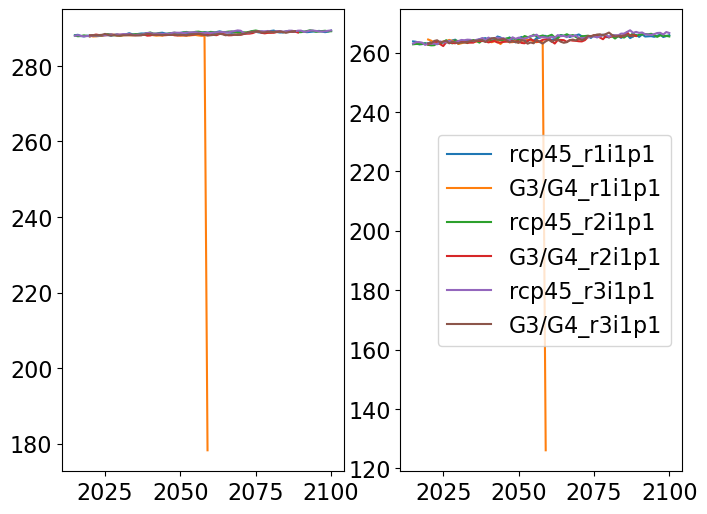

In [18]:
## check MPI, as ens mem 1 looks weird:
model = 'MPI-ESM-LR'
mod_df_g3 = g3_df[g3_df['Model'] == model]
mod_df_rcp45 = CMIP5_df[(CMIP5_df['Model'] == model) & (CMIP5_df['Experiment'] == 'rcp45')]

mod_df_g3 = mod_df_g3[mod_df_g3['Year'].between(2015, 2100)]
mod_df_rcp45 = mod_df_rcp45[mod_df_rcp45['Year'].between(2015, 2100)]

fig, axs = plt.subplots(1, 2, figsize=(8,6))


ax = axs[0]
for ens in mod_df_g3['Ensemble_member'].unique():
    # get timeseries:
    mod_ens_df_g3 = mod_df_g3[mod_df_g3['Ensemble_member'] == ens]
    mod_ens_df_rcp45 = mod_df_rcp45[mod_df_rcp45['Ensemble_member'] == ens]

    ax.plot(mod_ens_df_rcp45['Year'], mod_ens_df_rcp45['tas_global'], label='rcp45_{}'.format(ens))
    ax.plot(mod_ens_df_g3['Year'], mod_ens_df_g3['tas_global'], label='G3/G4_{}'.format(ens))

ax = axs[1]
for ens in mod_df_g3['Ensemble_member'].unique():
    # get timeseries:
    mod_ens_df_g3 = mod_df_g3[mod_df_g3['Ensemble_member'] == ens]
    mod_ens_df_rcp45 = mod_df_rcp45[mod_df_rcp45['Ensemble_member'] == ens]

    ax.plot(mod_ens_df_rcp45['Year'], mod_ens_df_rcp45['tas_arctic'], label='rcp45_{}'.format(ens))
    ax.plot(mod_ens_df_g3['Year'], mod_ens_df_g3['tas_arctic'], label='G3/G4_{}'.format(ens))

ax.legend()

## there is an issue with r1 data in the middle of the run, but doesn't seem to effect the assessment period, so leave this run in. 


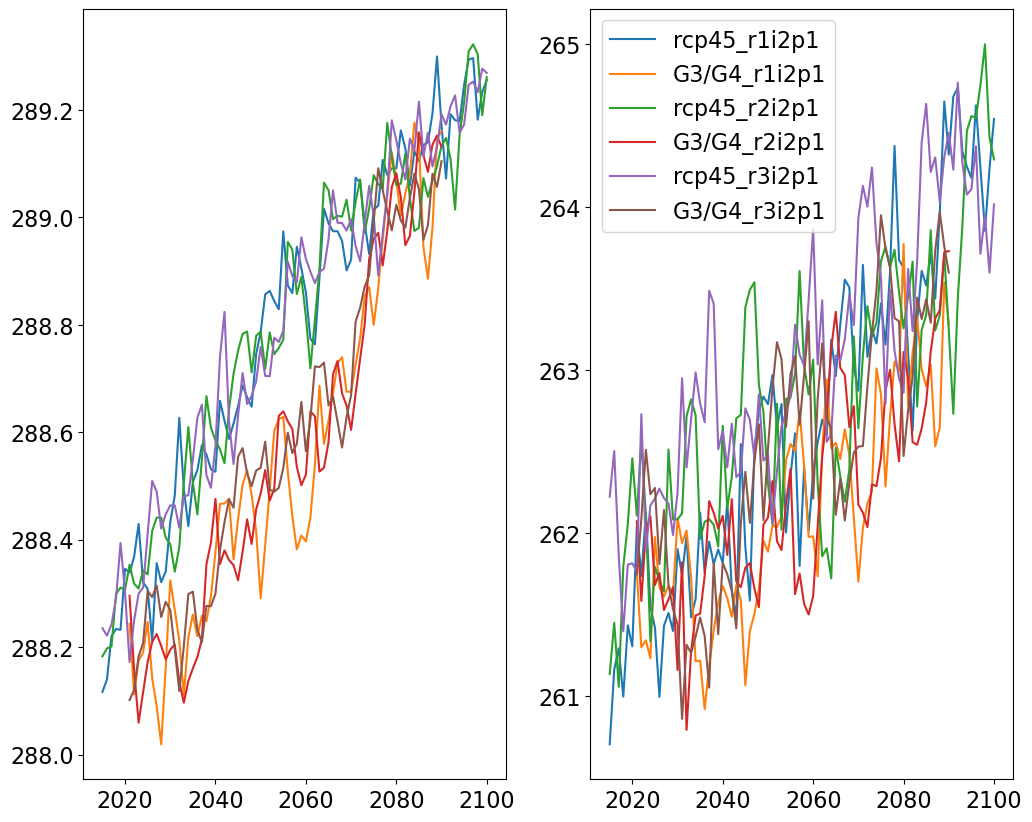

In [19]:
## also check CSIRO, as ens mem 3 looks weird:
model = 'CSIRO-Mk3L-1-2'
mod_df_g3 = g4_df[g4_df['Model'] == model]
mod_df_rcp45 = CMIP5_df[(CMIP5_df['Model'] == model) & (CMIP5_df['Experiment'] == 'rcp45')]

mod_df_g3 = mod_df_g3[mod_df_g3['Year'].between(2015, 2100)]
mod_df_rcp45 = mod_df_rcp45[mod_df_rcp45['Year'].between(2015, 2100)]

fig, axs = plt.subplots(1, 2, figsize=(12,10))


ax = axs[0]
for ens in mod_df_g3['Ensemble_member'].unique():
    # get timeseries:
    mod_ens_df_g3 = mod_df_g3[mod_df_g3['Ensemble_member'] == ens]
    mod_ens_df_rcp45 = mod_df_rcp45[mod_df_rcp45['Ensemble_member'] == ens]

    ax.plot(mod_ens_df_rcp45['Year'], mod_ens_df_rcp45['tas_global'], label='rcp45_{}'.format(ens))
    ax.plot(mod_ens_df_g3['Year'], mod_ens_df_g3['tas_global'], label='G3/G4_{}'.format(ens))

ax = axs[1]
for ens in mod_df_g3['Ensemble_member'].unique():
    # get timeseries:
    mod_ens_df_g3 = mod_df_g3[mod_df_g3['Ensemble_member'] == ens]
    mod_ens_df_rcp45 = mod_df_rcp45[mod_df_rcp45['Ensemble_member'] == ens]

    ax.plot(mod_ens_df_rcp45['Year'], mod_ens_df_rcp45['tas_arctic'], label='rcp45_{}'.format(ens))
    ax.plot(mod_ens_df_g3['Year'], mod_ens_df_g3['tas_arctic'], label='G3/G4_{}'.format(ens))

ax.legend()

## in this case, no obvious error - just a member that has low arctic response, so keep it in


In [20]:
out_df_G4

,warming_amp,cooling_amp_G3G4
BNU-ESM,[2.4685445943988986],[2.833352079778971]
CSIRO-Mk3L-1-2,"[1.4708319404055474, 1.1845765781676867, 2.025...","[1.2079501062852154, 1.4744282912519884, 0.118..."
GISS-E2-R,"[1.8859887596984737, 1.9910122171912934, 2.235...","[4.160029483892026, 3.653753595673118, 3.77390..."
HadGEM2-ES,"[3.307370575539906, 2.549573324949419, 3.03843...","[2.254928028058717, 2.3323920085975915, 2.7800..."
MIROC-ESM,[2.4789160196807525],[2.3807936508726155]
MIROC-ESM-CHEM,[2.576930673880839],[1.5573483678046205]
NorESM1-M,[2.5106303084192234],[2.402307732464388]
MPI-ESM-LR,"[2.589135275448093, 2.5113489522733374]","[2.2689032655743815, 2.478868398255142]"


In [31]:
## define new color dict with CMIP5 models too:
color_dict_G4 = {'BNU-ESM':'#e377c2',
                'CSIRO-Mk3L-1-2':'#7f7f7f',
                'GISS-E2-R':'#bcbd22',
                'HadGEM2-ES':'#17becf',
                'MIROC-ESM':'#aec7e8',
                'MIROC-ESM-CHEM':'#ffbb78',
                'NorESM1-M':'#c49c94',
                'MPI-ESM-LR':'#98df8a',
                'UKESM1-0-LL':'#1f77b4',
                'IPSL-CM6A-LR':'#ff7f0e',
                'MPI-ESM1-2-HR':'#2ca02c',
                'MPI-ESM1-2-LR':'#d62728',
                'CESM2-WACCM':'#9467bd',
                'CNRM-ESM2-1':'#8c564b'}


UKESM1-0-LL
IPSL-CM6A-LR
MPI-ESM1-2-HR
MPI-ESM1-2-LR
CESM2-WACCM
CNRM-ESM2-1
BNU-ESM
CSIRO-Mk3L-1-2
GISS-E2-R
HadGEM2-ES
MIROC-ESM
MIROC-ESM-CHEM
NorESM1-M
MPI-ESM-LR


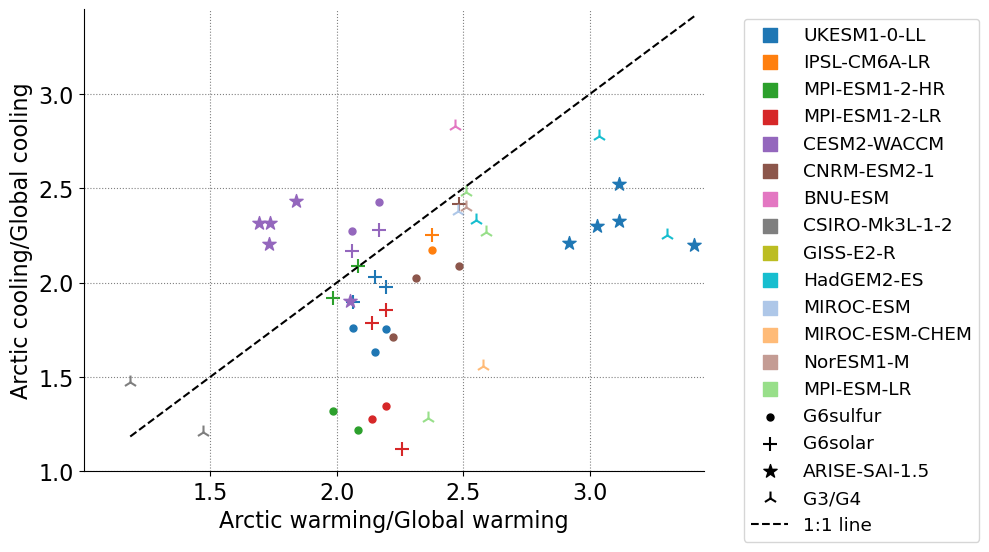

In [32]:
# scatter plot of out_df contents, plus also G3/G4 data:

fig, ax = plt.subplots(figsize=(8,6))

for model in models:
    print(model)
    ax.scatter(out_df.loc[model, 'warming_amp'][0:len(out_df.loc[model, 'cooling_amp_G6sulfur'])], out_df.loc[model, 'cooling_amp_G6sulfur'][0:len(out_df.loc[model, 'warming_amp'])], color=color_dict[model], marker='.', s=100)
    ax.scatter(out_df.loc[model, 'warming_amp'][0:len(out_df.loc[model, 'cooling_amp_G6solar'])], out_df.loc[model, 'cooling_amp_G6solar'][0:len(out_df.loc[model, 'warming_amp'])], color=color_dict[model], marker='+', s=100)
    if model in arise_mods:
        ax.scatter(out_df.loc[model, 'warming_amp_arise'][0:len(out_df.loc[model, 'cooling_amp_ARISE'])], out_df.loc[model, 'cooling_amp_ARISE'], color=color_dict[model], marker='*', s=100)

    # dummy scatters for the legend:
    ax.scatter([], [], label=model, color=color_dict[model], marker='s', s=100)

for model in out_df_G4.index.unique().values:
    print(model)
    ax.scatter(out_df_G4.loc[model, 'warming_amp'][0:len(out_df_G4.loc[model, 'cooling_amp_G3G4'])], out_df_G4.loc[model, 'cooling_amp_G3G4'], color=color_dict_G4[model], marker='2', s=100)

    # dummy scatters for the legend:
    ax.scatter([], [], label=model, color=color_dict_G4[model], marker='s', s=100)

# add legend for marker types:
ax.scatter([], [], label='G6sulfur', color='k', marker='.', s=100)
ax.scatter([], [], label='G6solar', color='k', marker='+', s=100)
ax.scatter([], [], label='ARISE-SAI-1.5', color='k', marker='*', s=100)
ax.scatter([], [], label='G3/G4', color='k', marker='2', s=100)

# one-to-one line
x = np.linspace(1.18457, 3.4135, 100)
ax.plot(x, x, color='k', linestyle='--', label='1:1 line')

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
ax.set_xlabel('Arctic warming/Global warming', fontsize='medium')
ax.set_ylabel('Arctic cooling/Global cooling', fontsize='medium')

ax.set_xlim([1, 3.45])
ax.set_ylim([1, 3.45])

ax.set_xticks(np.arange(1.5, 3.5, 0.5))
# remove right and top axes
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.grid(ls='dotted', c='gray')

plt.savefig('arctic_amp_warming_vs_cooling_GeoMIP_G6_G4G3_ARISE.png', bbox_inches='tight', dpi=300)